In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('C:\\Users\\soodr\\OneDrive\\Desktop\\Internship-project-Workora\\Task 3\\web_traffic_sample.csv')

In [3]:
df.head(5)

,SessionID,Date,PagePath,Source,DeviceCategory,SessionDurationSec,PageViews,Converted,BounceRate
0,SESS-5001,2026-06-10,/landing,Google Search,Mobile,145,3,Yes,0.0
1,SESS-5002,2026-06-10,/courses,Direct,Desktop,420,8,Yes,0.0
2,SESS-5003,2026-06-10,/blog/python,LinkedIn,Mobile,45,1,No,1.0
3,SESS-5004,2026-06-11,/register,Google Ads,Desktop,210,4,Yes,0.0
4,SESS-5005,2026-06-11,/pricing,Direct,Desktop,60,2,No,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SessionID           10 non-null     object 
 1   Date                10 non-null     object 
 2   PagePath            10 non-null     object 
 3   Source              10 non-null     object 
 4   DeviceCategory      10 non-null     object 
 5   SessionDurationSec  10 non-null     int64  
 6   PageViews           10 non-null     int64  
 7   Converted           10 non-null     object 
 8   BounceRate          10 non-null     float64
dtypes: float64(1), int64(2), object(6)
memory usage: 852.0+ bytes


In [5]:
df.shape

(10, 9)

In [6]:
df.describe(include='all')

,SessionID,Date,PagePath,Source,DeviceCategory,SessionDurationSec,PageViews,Converted,BounceRate
count,10,10,10,10,10,10.000000,10.000000,10,10.000000
unique,10,3,8,6,2,NaN,NaN,2,NaN
top,SESS-5001,2026-06-12,/landing,Direct,Mobile,NaN,NaN,Yes,NaN
freq,1,4,3,3,5,NaN,NaN,5,NaN
mean,NaN,NaN,NaN,NaN,NaN,170.500000,3.400000,NaN,0.300000
std,NaN,NaN,NaN,NaN,NaN,137.506565,2.366432,NaN,0.483046
min,NaN,NaN,NaN,NaN,NaN,15.000000,1.000000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,48.750000,1.250000,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,162.500000,3.000000,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,270.000000,4.750000,NaN,0.750000


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df['Converted'] = df['Converted'].astype(str).str.strip().str.lower().map({'yes': True, 'no': False})
df['Bounce'] = (df['BounceRate'] >= 1.0) | (df['PageViews'] == 1) 


In [9]:
overall_bounce_rate = df['Bounce'].mean()

overall_conversion_rate = df['Converted'].mean()


In [10]:
by_source = df.groupby('Source').agg(
    sessions=('SessionID', 'nunique'),
    bounce_rate=('Bounce', 'mean'),
    avg_session_sec=('SessionDurationSec', 'mean'),
    avg_pageviews=('PageViews', 'mean'),
    conversion_rate=('Converted', 'mean')
).reset_index().sort_values('sessions', ascending=False)

In [15]:
df['week'] = df['Date'].dt.to_period('W').apply(lambda p: p.start_time)
cohort_stats = df.groupby('week').agg(
    sessions=('SessionID', 'nunique'),
    avg_session_sec=('SessionDurationSec', 'mean'),
    avg_pageviews=('PageViews', 'mean'),
    bounce_rate=('Bounce', 'mean'),
    conversion_rate=('Converted', 'mean')
).reset_index()

In [16]:
page_stats = df.groupby('PagePath').agg(
    page_sessions=('SessionID', 'nunique'),
    bounce_rate=('Bounce', 'mean'),
    conversion_rate=('Converted', 'mean'),
    avg_pageviews=('PageViews', 'mean')
).reset_index()
top_dropoffs = page_stats.sort_values(['bounce_rate', 'conversion_rate'], ascending=[False, True]).head(10)


C:\Users\soodr\AppData\Local\Temp\ipykernel_17648\1780817773.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=by_source, x='conversion_rate', y='Source', palette='viridis')


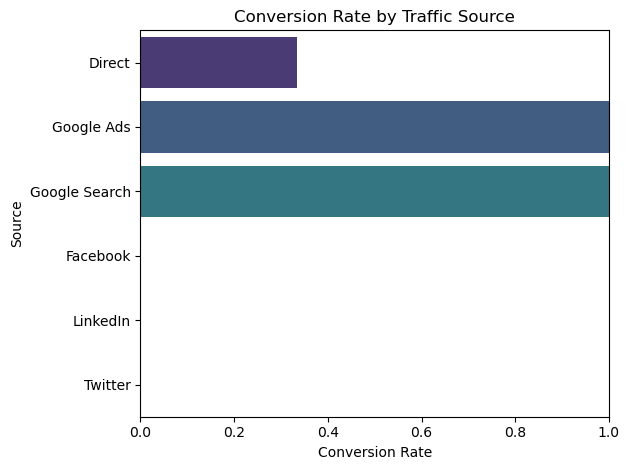

In [17]:
plt.figure()
sns.barplot(data=by_source, x='conversion_rate', y='Source', palette='viridis')
plt.xlim(0, 1)
plt.xlabel("Conversion Rate")
plt.title("Conversion Rate by Traffic Source")
plt.tight_layout()

C:\Users\soodr\AppData\Local\Temp\ipykernel_17648\3669537114.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=by_source, x='bounce_rate', y='Source', palette='magma')


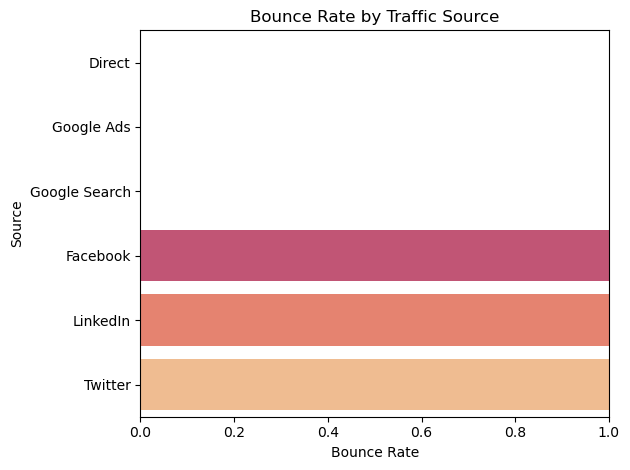

In [18]:
plt.figure()
sns.barplot(data=by_source, x='bounce_rate', y='Source', palette='magma')
plt.xlim(0, 1)
plt.xlabel("Bounce Rate")
plt.title("Bounce Rate by Traffic Source")
plt.tight_layout()

C:\Users\soodr\AppData\Local\Temp\ipykernel_17648\2174846811.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=by_source, x='avg_session_sec', y='Source', palette='cubehelix')


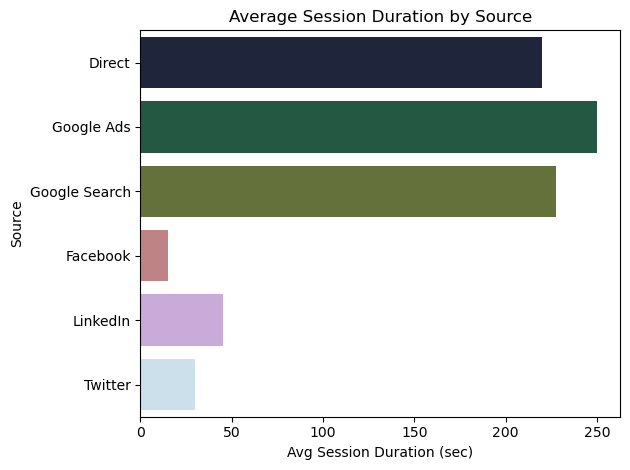

In [19]:
plt.figure()
sns.barplot(data=by_source, x='avg_session_sec', y='Source', palette='cubehelix')
plt.xlabel("Avg Session Duration (sec)")
plt.title("Average Session Duration by Source")
plt.tight_layout()

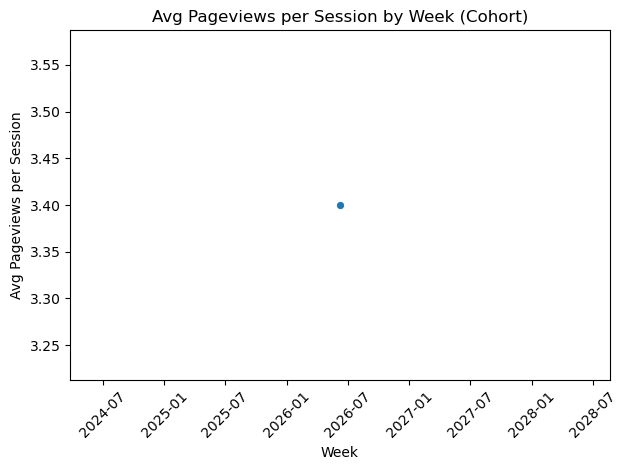

In [20]:
plt.figure()
sns.lineplot(data=cohort_stats, x='week', y='avg_pageviews', marker='o')
plt.xlabel("Week")
plt.ylabel("Avg Pageviews per Session")
plt.title("Avg Pageviews per Session by Week (Cohort)")
plt.xticks(rotation=45)
plt.tight_layout()

C:\Users\soodr\AppData\Local\Temp\ipykernel_17648\915296742.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_dropoffs, x='bounce_rate', y='PagePath', palette='rocket')


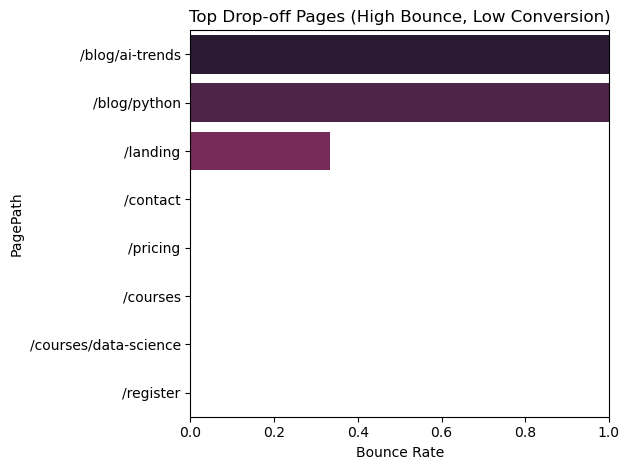

In [21]:
plt.figure()
sns.barplot(data=top_dropoffs, x='bounce_rate', y='PagePath', palette='rocket')
plt.xlim(0, 1)
plt.xlabel("Bounce Rate")
plt.title("Top Drop-off Pages (High Bounce, Low Conversion)")
plt.tight_layout()

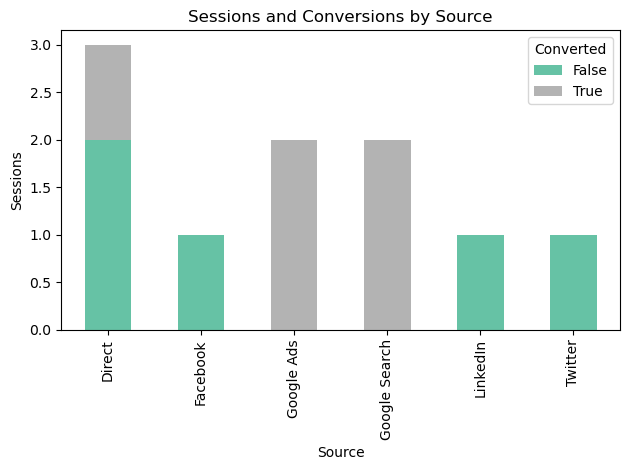

In [22]:
funnel_df = df.groupby(['Source', 'Converted']).size().unstack(fill_value=0)
funnel_df = funnel_df.sort_values(by=False, ascending=False) if False else funnel_df  # keep original
funnel_df.plot(kind='bar', stacked=True, colormap='Set2')
plt.ylabel("Sessions")
plt.title("Sessions and Conversions by Source")
plt.tight_layout()